<a href="https://colab.research.google.com/github/osaruchan2424/QuantHWs/blob/main/HW3_Fernandez_Meza_Suga_Xu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Problem Set 3
Students:<br>
Francisco Fernandez<br>Mauricio Meza<br>Satoshi Suga<br>Alex Xu

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def replace_missing(df):
    return df.replace([-99.99, -999, -99.9, -99], np.nan).infer_objects(copy=False)

In [ ]:
mkt_data = replace_missing(pd.read_excel('Problem_Set3.xls', sheet_name='Market_proxy', skiprows=5, index_col=0, header=0))
equity_risk_prem = mkt_data['Mkt-RF']
riskfree_rate = mkt_data['RF']

ind_returns = replace_missing(pd.read_excel('Problem_Set3.xls', sheet_name='49_Industry_Portfolios', skiprows=6, index_col=0, header=0, usecols="A:AX", nrows=1085))
ind_size = replace_missing(pd.read_excel('Problem_Set3.xls', sheet_name='49_Industry_Portfolios', skiprows=6, index_col=0, header=0, usecols="AZ:CW", nrows=1085))
ind_beme = replace_missing(pd.read_excel('Problem_Set3.xls', sheet_name='49_Industry_Portfolios', skiprows=6, index_col=0, header=0, usecols="CY:EV", nrows=91))

ind_size.columns = ind_returns.columns
ind_beme.columns = ind_returns.columns


a) For Sharpe-Lintner: γ0 should equal to 0 as the only risk rewarded should be the market's. γM should be equal to the empirical market risk premium. For Black's CAPM, allowing for short sales, therefore the creation of a zero Beta portfolio uncorrelated with the market: γ0 represents the return of the zero Beta portfolio. γM represents the premium of the market portfolio above the zero Beta portfolio.  

b) 1.

In [ ]:
def calculate_beta(returns_table, market_proxy, rf_proxy):
    """
    Calculate beta for each industry/asset using excess returns

    Formula: βiM = cov(Ri - RF, Mkt-RF) / σ²(Mkt-RF)
    Where: Ri = industry returns, RF = risk-free rate, Mkt-RF = market excess returns (already calculated)

    Parameters:
    - returns_table: DataFrame with industry/asset returns (rows=dates, cols=industries)
    - market_proxy_table: DataFrame with market proxy data
    - market_column: Column name for market excess returns (default: 'Mkt-RF')
    - rf_column: Column name for risk-free rate (default: 'RF')

    Returns:
    - Series with beta values for each industry/asset
    """
    # Align returns and market proxy on common dates
    common_dates = returns_table.index.intersection(market_proxy.index)
    returns_aligned = returns_table.loc[common_dates]
    market_proxy_aligned = market_proxy.loc[common_dates]
    riskfree_rate_aligned = rf_proxy.loc[common_dates]

    # Get market excess returns (Mkt-RF is already market return - risk-free rate)
    market_excess_returns = pd.to_numeric(market_proxy_aligned, errors='coerce')
    risk_free_rate = pd.to_numeric(riskfree_rate_aligned, errors='coerce')

    # Calculate market excess returns variance (skip NaN values)
    market_excess_variance = market_excess_returns.var()

    # Calculate beta for each port
    betas = {}

    for port in returns_aligned.columns:
        # Get port returns and clean data
        port_returns = pd.to_numeric(returns_aligned[port], errors='coerce')

        # Calculate port excess returns (port returns - risk-free rate)
        port_excess_returns = port_returns - risk_free_rate

        # Calculate covariance between port excess returns and market excess returns
        covariance = port_excess_returns.cov(market_excess_returns)

        # Calculate beta
        beta = covariance / market_excess_variance
        betas[port] = beta

    # Convert to Series
    beta_series = pd.Series(betas, name='Beta', index=returns_table.columns)


    return beta_series

def calculate_average_returns(returns_table, market_proxy_table=None, rf_proxy=None):
    """
    Calculate average excess returns for each industry/column in the returns table

    Parameters:
    - returns_table: DataFrame with industry/asset returns (rows=dates, cols=industries)
    - market_proxy_table: DataFrame with market proxy data (optional, for excess returns)
    - rf_column: Column name for risk-free rate (default: 'RF')

    Returns:
    - Series with average excess returns for each industry/asset
    """
    # Clean the data by converting to numeric, replacing non-numeric values with NaN
    cleaned_table = returns_table.apply(pd.to_numeric, errors='coerce')

    if market_proxy_table is not None:
        # Calculate excess returns by subtracting risk-free rate
        common_dates = cleaned_table.index.intersection(market_proxy_table.index)
        returns_aligned = cleaned_table.loc[common_dates]
        rf_proxy_aligned = rf_proxy.loc[common_dates]
        risk_free_rate = pd.to_numeric(rf_proxy_aligned, errors='coerce')
        excess_returns = returns_aligned.sub(risk_free_rate, axis=0)

        # Calculate average excess returns for each column, skipping NaN values
        average_excess_returns = excess_returns.mean()
    else:
        # If no market proxy provided, just return average raw returns
        average_excess_returns = cleaned_table.mean()

    # Convert to Series with proper name
    average_excess_returns = pd.Series(average_excess_returns, name='Average Excess Return')

    return average_excess_returns

def linear_regression(dependent_var, independent_var, verbose=True):
    """
    OLS y = a + b x + e using scipy.linregress for b and a,
    then compute additional stats with correct SE(a).

    Parameters:
    - dependent_var: Series or array of dependent variable (y)
    - independent_var: Series or array of independent variable (x)
    - verbose: Boolean to control whether to print results (default: True)
    """

    y = np.asarray(dependent_var, dtype=float)
    x = np.asarray(independent_var, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    n = x.size
    if n < 3:
        raise ValueError("Need at least 3 valid observations.")
    if np.allclose(x, x.mean()):
        raise ValueError("X has (near) zero variance; slope undefined.")

    # primary estimates via scipy
    slope, intercept, r_value, p_value_slope, se_slope = stats.linregress(x, y)
    r_squared = r_value ** 2

    # fitted values and residuals
    y_hat = intercept + slope * x
    resid = y - y_hat

    # residual std. error (a.k.a. sigma-hat)
    s2 = (resid @ resid) / (n - 2)
    se_regression = np.sqrt(s2)

    # pieces for SEs
    xbar = x.mean()
    Sxx = np.sum((x - xbar) ** 2)

    # correct SE(intercept) and t-stat
    se_intercept = se_regression * np.sqrt(1.0/n + (xbar**2) / Sxx)
    t_stat_intercept = intercept / se_intercept

    # slope t-stat matches scipy: slope / se_slope
    t_stat_slope = slope / se_slope

    # p-value for intercept (two-sided)
    t = stats.t(df=n-2)
    p_value_intercept = 2 * (1 - t.cdf(abs(t_stat_intercept)))

    mse = float(s2)
    rmse = np.sqrt(mse)

    return {
        "intercept": intercept,
        "slope": slope,
        "r_squared": r_squared,
        "correlation": r_value,
        "std_error_slope": se_slope,
        "std_error_intercept": se_intercept,
        "std_error_regression": se_regression,
        "t_stat_slope": t_stat_slope,
        "t_stat_intercept": t_stat_intercept,
        "p_value_slope": p_value_slope,
        "p_value_intercept": p_value_intercept,
        "n_observations": n,
        "mse": mse,
        "rmse": rmse,
    }

industry_betas = calculate_beta(ind_returns, equity_risk_prem, riskfree_rate)

ind_avg_returns = calculate_average_returns(ind_returns, market_proxy_table=equity_risk_prem, rf_proxy=riskfree_rate)
print(industry_betas)



Agric    0.917150
Food     0.725443
Soda     0.564670
Beer     0.942062
Smoke    0.628665
Toys     1.207596
Fun      1.421768
Books    1.116615
Hshld    0.902271
Clths    0.813177
Hlth     0.809720
MedEq    0.837705
Drugs    0.836520
Chems    1.042579
Rubbr    1.205600
Txtls    1.138909
BldMt    1.159646
Cnstr    1.355373
Steel    1.357006
FabPr    0.755915
Mach     1.243169
ElcEq    1.284064
Autos    1.252084
Aero     1.306059
Ships    1.167509
Guns     0.569371
Gold     0.410884
Mines    0.974484
Coal     1.299820
Oil      0.868141
Util     0.778292
Telcm    0.661480
PerSv    1.099471
BusSv    0.889436
Hardw    1.115375
Softw    1.144689
Chips    1.343525
LabEq    0.995773
Paper    1.700402
Boxes    0.952911
Trans    1.137611
Whlsl    1.089085
Rtail    0.965016
Meals    0.945508
Banks    1.044185
Insur    1.120373
RlEst    1.278710
Fin      1.306127
Other    1.054568
Name: Beta, dtype: float64


b) 2.

In [ ]:
# Cross-sectional regression of excess returns and static betas to find gamma coefficients

def cross_sectional_reg(return_series, betas_series, rf_rate_series):
    """""
    Returns a dictionary of cross-sectional coefficients, tstats and p-values
    """""
    ind_exc_returns = pd.DataFrame(columns=return_series.columns)
    for c in return_series.columns:
        ind_exc_returns[c] = return_series[c] - rf_rate_series

    cs_results_list = []
    for index, row in ind_exc_returns.iterrows():
        cs_result = linear_regression(row.values, betas_series, verbose=False)
        cs_result["date"] = index
        cs_results_list.append(cs_result)

    cs_regression = pd.DataFrame(cs_results_list)
    cs_regression.set_index('date', inplace=True)

    # Calculate estimates
    avg_gamma0 = cs_regression['intercept'].mean()
    avg_gammaM = cs_regression['slope'].mean()
    stderr_gamma0 = cs_regression['intercept'].std() / np.sqrt(len(cs_regression))
    stderr_gammaM = cs_regression['slope'].std() / np.sqrt(len(cs_regression))

    # Calculate the t-statistic for each average
    # The formula is: average / standard_error
    tstat_gamma0 = avg_gamma0 / stderr_gamma0
    tstat_gammaM = avg_gammaM / stderr_gammaM

    p_value_g0 = 2 * (1 - stats.t.cdf(np.abs(tstat_gamma0), df=len(cs_regression)-1))
    p_value_gM = 2 * (1 - stats.t.cdf(np.abs(tstat_gammaM), df=len(cs_regression)-1))

    print(f"Estimate for gamma_0: {avg_gamma0:.4f}")
    print(f"Estimate for gamma_M: {avg_gammaM:.4f}")
    print(f"P-value for gamma_0: {p_value_g0:.4f}")
    print(f"P-value for gamma_M: {p_value_gM:.4f}")

    cs_reg_results = [{
        'avg_gamma0': avg_gamma0,
        'avg_gammaM': avg_gammaM,
        'tstat_gamma0': tstat_gamma0,
        'tstat_gammaM': tstat_gammaM,
        'p_value_g0': p_value_g0,
        'p_value_gM': p_value_gM
    }]

    return cs_reg_results

cs_1 = cross_sectional_reg(ind_returns, industry_betas, riskfree_rate)



Estimate for gamma_0: 0.5094
Estimate for gamma_M: 0.2379
P-value for gamma_0: 0.0064
P-value for gamma_M: 0.3302


c)

In [ ]:
simple_reg_results = linear_regression(ind_avg_returns, industry_betas, verbose=False)
print(f"Estimate for gamma_0: {simple_reg_results['intercept']}")
print(f"Estimate for gamma_M: {simple_reg_results['slope']}")
print(f"P-value for gamma_0: {simple_reg_results['p_value_intercept']}")
print(f"P-value for gamma_M: {simple_reg_results['p_value_slope']}")


Estimate for gamma_0: 0.5271147538571758
Estimate for gamma_M: 0.21291403503057707
P-value for gamma_0: 1.2111465141906308e-07
P-value for gamma_M: 0.010069039140212637


The standard errors from the Fama-MacBeth procedure are larger than those from the single cross-sectional regression:

This is a more accurate reflection of the true uncertainty of the estimates. The smaller standard errors produced by the simple cross-sectional regression are artificially low and misleading due to errors-in-variables problem (being the betas estimates from the first-stage regressions) and the correlation of residuals (because of the correlation of the portfolios and the market) that the simple regression ignores.

d)

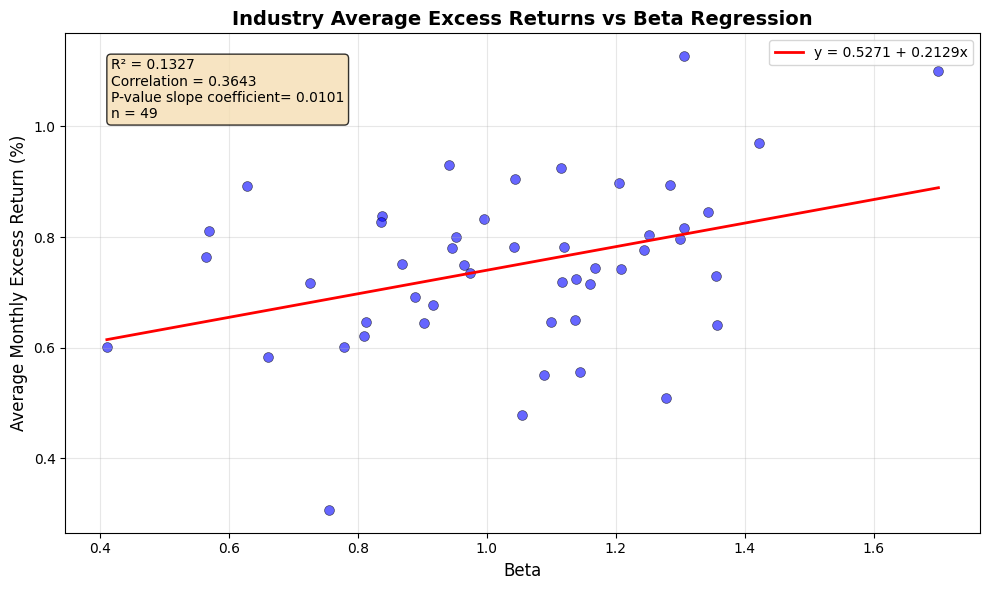

In [ ]:
def plot_regression(dependent_var, independent_var, regression_results, title="Regression Plot", xlabel="Independent Variable", ylabel="Dependent Variable", show_plot=True, save_plot=False):
    """
    Create a scatter plot with regression line

    Parameters:
    - dependent_var: Series or array of dependent variable (y)
    - independent_var: Series or array of independent variable (x)
    - regression_results: Dictionary with regression statistics
    - title: Plot title
    - xlabel: X-axis label
    - ylabel: Y-axis label
    - show_plot: Boolean to control whether to display the plot (default: True)
    - save_plot: Boolean to control whether to return the figure for PDF saving (default: False)
    """
    # Convert to numpy arrays and remove any NaN values
    y = np.asarray(dependent_var, dtype=float)
    x = np.asarray(independent_var, dtype=float)

    # Create mask to remove NaN values
    mask = np.isfinite(x) & np.isfinite(y)
    x_clean = x[mask]
    y_clean = y[mask]

    # Create the plot
    fig = plt.figure(figsize=(10, 6))

    # Scatter plot
    plt.scatter(x_clean, y_clean, alpha=0.6, s=50, color='blue', edgecolors='black', linewidth=0.5)

    # Regression line
    x_line = np.linspace(x_clean.min(), x_clean.max(), 100)
    y_line = regression_results['intercept'] + regression_results['slope'] * x_line
    plt.plot(x_line, y_line, 'r-', linewidth=2, label=f"y = {regression_results['intercept']:.4f} + {regression_results['slope']:.4f}x")

    # Add labels and title
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')

    # Add R-squared and other stats to the plot
    stats_text = f"R² = {regression_results['r_squared']:.4f}\n"
    stats_text += f"Correlation = {regression_results['correlation']:.4f}\n"
    stats_text += f"P-value slope coefficient= {regression_results['p_value_slope']:.4f}\n"
    stats_text += f"n = {regression_results['n_observations']}"

    plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
             fontsize=10)

    # Add legend
    plt.legend(loc='best')

    # Add grid
    plt.grid(True, alpha=0.3)

    # Adjust layout
    plt.tight_layout()

    # Show the plot only if requested
    if show_plot:
        plt.show()
    else:
        plt.close()  # Close the figure to free memory

    # Return figure for PDF saving if requested
    if save_plot:
        return fig
    else:
        return None

fig1 = plot_regression(ind_avg_returns, industry_betas, simple_reg_results,
                       title="Industry Average Excess Returns vs Beta Regression",
                       xlabel="Beta",
                       ylabel="Average Monthly Excess Return (%)",
                       show_plot=True, save_plot=True)



The relation should be positive as the larger the Beta (market risk) of the portfolio, the larger the return should be.

e)

Ri = γ₀ + γM βiM + γsize ln(size) + γB/M ln(BE/ME) + ηi
BE/ME data shape: (91, 49)
Returns data shape: (1085, 49)
Size data shape: (1085, 49)
Common dates for regression: 1085 months
Regression dataset prepared: 50216 observations
Industries: 49
Months: 1085
Ri = γ₀ + γM βiM + γsize ln(size) + γB/M ln(BE/ME) + ηi

EXTENDED CROSS-SECTIONAL REGRESSION RESULTS
Ri = γ₀ + γM βiM + γsize ln(size) + γB/M ln(BE/ME) + ηi
Note: Using actual returns (not excess returns)

Intercept (γ₀):     1.727499  (SE: 0.203623, t:    8.484)
Beta (γM):          0.090975  (SE: 0.148106, t:    0.614)
Size (γsize):       -0.183072  (SE: 0.022936, t:   -7.982)
BE/ME (γB/M):       -0.389490  (SE: 0.067459, t:   -5.774)

R-squared:          0.001324
Observations:          50216
Industries:               49
Months:                 1085


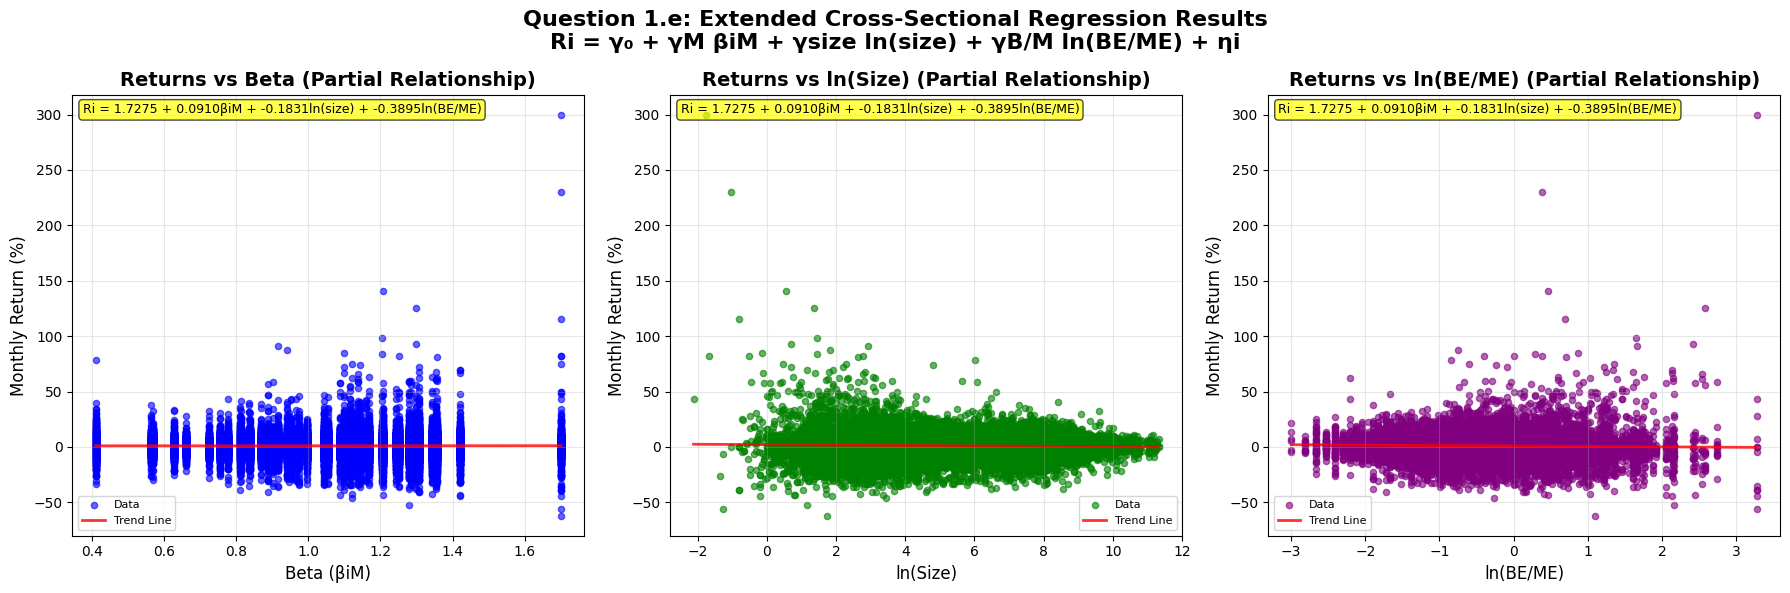

In [ ]:
def yearly_to_monthly(monthly_df, yearly_df):
    monthly_structure = pd.DataFrame(columns=['year'], index=monthly_df.index)
    monthly_structure['year'] = monthly_df.index // 100
    yearly_to_monthly_df = pd.merge(monthly_structure, yearly_df, left_on='year', right_index=True, how='left')
    new_monthly_df = yearly_to_monthly_df.drop(columns='year')

    return new_monthly_df


print("Ri = γ₀ + γM βiM + γsize ln(size) + γB/M ln(BE/ME) + ηi")

# 1. Get monthly size data
monthly_ind_size = ind_size

# 2. Prepare annual BE/ME data - replicate each year for all months in that year
print(f"BE/ME data shape: {ind_beme.shape}")
print(f"Returns data shape: {ind_returns.shape}")
print(f"Size data shape: {monthly_ind_size.shape}")

# Create a DataFrame to store monthly BE/ME data
# monthly_beme = pd.DataFrame(index=portfolios_returns.index, columns=portfolios_returns.columns)

monthly_ind_beme = yearly_to_monthly(ind_returns, ind_beme)

# 3. Align all data on common dates
common_dates = ind_returns.index.intersection(monthly_ind_size.index).intersection(monthly_ind_beme.index)
print(f"Common dates for regression: {len(common_dates)} months")

returns_aligned = ind_returns.loc[common_dates]  # Actual returns
ind_size_aligned = monthly_ind_size.loc[common_dates]
ind_beme_aligned = monthly_ind_beme.loc[common_dates]
ind_betas_aligned = industry_betas  # Same for all months

# Flatten data for regression (stack all industries and months)
regression_data = []

for date in common_dates:
    for industry in returns_aligned.columns:
        # Get values for this industry and date
        return_val = returns_aligned.loc[date, industry]
        size_val = ind_size_aligned.loc[date, industry]
        beme_val = ind_beme_aligned.loc[date, industry]
        beta_val = ind_betas_aligned[industry]

        # Skip if any value is NaN
        if pd.isna(return_val) or pd.isna(size_val) or pd.isna(beme_val) or pd.isna(beta_val):
            continue

        # Take natural log of size and BE/ME
        ln_size = np.log(size_val)
        ln_beme = np.log(beme_val)

        regression_data.append({
            'date': date,
            'industry': industry,
            'return': return_val,
            'beta': beta_val,
            'ln_size': ln_size,
            'ln_beme': ln_beme
        })

# Convert to DataFrame
reg_df = pd.DataFrame(regression_data)
print(f"Regression dataset prepared: {len(reg_df)} observations")
print(f"Industries: {reg_df['industry'].nunique()}")
print(f"Months: {reg_df['date'].nunique()}")

# 6. Run the extended regression using multiple regression
print("Ri = γ₀ + γM βiM + γsize ln(size) + γB/M ln(BE/ME) + ηi")

# Prepare data for regression
y = reg_df['return'].values
X = reg_df[['beta', 'ln_size', 'ln_beme']].values

# Add constant term for intercept
X_with_const = np.column_stack([np.ones(len(X)), X])

# Run OLS regression
try:

    # Fit the model
    model = LinearRegression(fit_intercept=False)  # We added constant manually
    model.fit(X_with_const, y)

    # Get coefficients
    intercept = model.coef_[0]
    beta_coef = model.coef_[1]
    size_coef = model.coef_[2]
    beme_coef = model.coef_[3]

    # Get predictions and R-squared
    y_pred = model.predict(X_with_const)
    r_squared = r2_score(y, y_pred)

    # Calculate standard errors (simplified)
    residuals = y - y_pred
    mse = np.mean(residuals**2)
    n = len(y)
    p = X_with_const.shape[1]  # number of parameters

    # Standard errors (simplified calculation)
    XtX_inv = np.linalg.inv(X_with_const.T @ X_with_const)
    se_matrix = mse * XtX_inv
    se_intercept = np.sqrt(se_matrix[0, 0])
    se_beta = np.sqrt(se_matrix[1, 1])
    se_size = np.sqrt(se_matrix[2, 2])
    se_beme = np.sqrt(se_matrix[3, 3])

    # T-statistics
    t_intercept = intercept / se_intercept
    t_beta = beta_coef / se_beta
    t_size = size_coef / se_size
    t_beme = beme_coef / se_beme

    # Print results
    print("\n" + "="*80)
    print("EXTENDED CROSS-SECTIONAL REGRESSION RESULTS")
    print("="*80)
    print(f"Ri = γ₀ + γM βiM + γsize ln(size) + γB/M ln(BE/ME) + ηi")
    print("Note: Using actual returns (not excess returns)")
    print()
    print(f"Intercept (γ₀):     {intercept:8.6f}  (SE: {se_intercept:8.6f}, t: {t_intercept:8.3f})")
    print(f"Beta (γM):          {beta_coef:8.6f}  (SE: {se_beta:8.6f}, t: {t_beta:8.3f})")
    print(f"Size (γsize):       {size_coef:8.6f}  (SE: {se_size:8.6f}, t: {t_size:8.3f})")
    print(f"BE/ME (γB/M):       {beme_coef:8.6f}  (SE: {se_beme:8.6f}, t: {t_beme:8.3f})")
    print()
    print(f"R-squared:          {r_squared:8.6f}")
    print(f"Observations:       {n:8d}")
    print(f"Industries:         {reg_df['industry'].nunique():8d}")
    print(f"Months:             {reg_df['date'].nunique():8d}")



    # Store results for potential plotting
    extended_regression_results = {
        'intercept': intercept,
        'beta_coef': beta_coef,
        'size_coef': size_coef,
        'beme_coef': beme_coef,
        'se_intercept': se_intercept,
        'se_beta': se_beta,
        'se_size': se_size,
        'se_beme': se_beme,
        't_intercept': t_intercept,
        't_beta': t_beta,
        't_size': t_size,
        't_beme': t_beme,
        'r_squared': r_squared,
        'n_observations': n
    }

except ImportError:
    print("Error: scikit-learn not available. Install with: pip install scikit-learn")
    print("Using alternative regression method...")

    # Alternative using numpy
    try:
        # Normal equation: β = (X'X)^(-1)X'y
        XtX = X_with_const.T @ X_with_const
        XtX_inv = np.linalg.inv(XtX)
        Xty = X_with_const.T @ y
        coeffs = XtX_inv @ Xty

        intercept = coeffs[0]
        beta_coef = coeffs[1]
        size_coef = coeffs[2]
        beme_coef = coeffs[3]

        # Calculate R-squared
        y_pred = X_with_const @ coeffs
        r_squared = 1 - np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2)

        print(f"Intercept (γ₀):     {intercept:8.6f}")
        print(f"Beta (γM):          {beta_coef:8.6f}")
        print(f"Size (γsize):       {size_coef:8.6f}")
        print(f"BE/ME (γB/M):       {beme_coef:8.6f}")
        print(f"R-squared:          {r_squared:8.6f}")
        print(f"Observations:       {len(y):8d}")

        # Store results for plotting (numpy fallback)
        extended_regression_results = {
            'intercept': intercept,
            'beta_coef': beta_coef,
            'size_coef': size_coef,
            'beme_coef': beme_coef,
            'r_squared': r_squared,
            'n_observations': len(y)
        }

    except Exception as e:
        print(f"Error in regression: {e}")
        # Set default values if regression fails
        extended_regression_results = None

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Question 1.e: Extended Cross-Sectional Regression Results\nRi = γ₀ + γM βiM + γsize ln(size) + γB/M ln(BE/ME) + ηi', fontsize=16, fontweight='bold')
if 'extended_regression_results' in locals() and extended_regression_results is not None:
    intercept = extended_regression_results['intercept']
    beta_coef = extended_regression_results['beta_coef']
    size_coef = extended_regression_results['size_coef']
    beme_coef = extended_regression_results['beme_coef']

    # Calculate fitted values for plotting
    y_fitted = X_with_const @ np.array([intercept, beta_coef, size_coef, beme_coef])

    # Plot 1: Returns vs Beta (with partial relationship from full regression)
    axes[0].scatter(reg_df['beta'], reg_df['return'], alpha=0.6, s=20, color='blue', label='Data')

    # Create trend line using the regression coefficient for beta
    # For the partial relationship, we need to hold other variables constant at their means
    mean_ln_size = reg_df['ln_size'].mean()
    mean_ln_beme = reg_df['ln_beme'].mean()

    # Partial relationship: Ri = γ₀ + γM βiM + γsize * mean_ln_size + γB/M * mean_ln_beme
    beta_range = np.linspace(reg_df['beta'].min(), reg_df['beta'].max(), 100)
    partial_returns_beta = intercept + beta_coef * beta_range + size_coef * mean_ln_size + beme_coef * mean_ln_beme

    axes[0].plot(beta_range, partial_returns_beta, "r-", alpha=0.8, linewidth=2, label='Trend Line')

    axes[0].set_xlabel('Beta (βiM)', fontsize=12)
    axes[0].set_ylabel('Monthly Return (%)', fontsize=12)
    axes[0].set_title('Returns vs Beta (Partial Relationship)', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(fontsize=8)

    # Add equation text box
    equation_text = f'Ri = {intercept:.4f} + {beta_coef:.4f}βiM + {size_coef:.4f}ln(size) + {beme_coef:.4f}ln(BE/ME)'
    axes[0].text(0.02, 0.98, equation_text, transform=axes[0].transAxes,
                 fontsize=9, verticalalignment='top',
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

    # Plot 2: Returns vs Size (ln) (with partial relationship from full regression)
    axes[1].scatter(reg_df['ln_size'], reg_df['return'], alpha=0.6, s=20, color='green', label='Data')

    # Partial relationship: Ri = γ₀ + γM * mean_beta + γsize ln(size) + γB/M * mean_ln_beme
    mean_beta = reg_df['beta'].mean()
    size_range = np.linspace(reg_df['ln_size'].min(), reg_df['ln_size'].max(), 100)
    partial_returns_size = intercept + beta_coef * mean_beta + size_coef * size_range + beme_coef * mean_ln_beme

    axes[1].plot(size_range, partial_returns_size, "r-", alpha=0.8, linewidth=2, label='Trend Line')

    axes[1].set_xlabel('ln(Size)', fontsize=12)
    axes[1].set_ylabel('Monthly Return (%)', fontsize=12)
    axes[1].set_title('Returns vs ln(Size) (Partial Relationship)', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(fontsize=8)

    # Add equation text box
    equation_text = f'Ri = {intercept:.4f} + {beta_coef:.4f}βiM + {size_coef:.4f}ln(size) + {beme_coef:.4f}ln(BE/ME)'
    axes[1].text(0.02, 0.98, equation_text, transform=axes[1].transAxes,
                 fontsize=9, verticalalignment='top',
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

    # Plot 3: Returns vs BE/ME (ln) (with partial relationship from full regression)
    axes[2].scatter(reg_df['ln_beme'], reg_df['return'], alpha=0.6, s=20, color='purple', label='Data')

    # Partial relationship: Ri = γ₀ + γM * mean_beta + γsize * mean_ln_size + γB/M ln(BE/ME)
    beme_range = np.linspace(reg_df['ln_beme'].min(), reg_df['ln_beme'].max(), 100)
    partial_returns_beme = intercept + beta_coef * mean_beta + size_coef * mean_ln_size + beme_coef * beme_range

    axes[2].plot(beme_range, partial_returns_beme, "r-", alpha=0.8, linewidth=2, label='Trend Line')

    axes[2].set_xlabel('ln(BE/ME)', fontsize=12)
    axes[2].set_ylabel('Monthly Return (%)', fontsize=12)
    axes[2].set_title('Returns vs ln(BE/ME) (Partial Relationship)', fontsize=14, fontweight='bold')
    axes[2].grid(True, alpha=0.3)
    axes[2].legend(fontsize=8)

    # Add equation text box
    equation_text = f'Ri = {intercept:.4f} + {beta_coef:.4f}βiM + {size_coef:.4f}ln(size) + {beme_coef:.4f}ln(BE/ME)'
    axes[2].text(0.02, 0.98, equation_text, transform=axes[2].transAxes,
                 fontsize=9, verticalalignment='top',
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

else:
    # Fallback: simple bivariate plots if regression results not available
    print("Warning: Using simple bivariate relationships (regression results not available)")

    # Plot 1: Returns vs Beta
    axes[0].scatter(reg_df['beta'], reg_df['return'], alpha=0.6, s=20, color='blue')
    z_beta = np.polyfit(reg_df['beta'], reg_df['return'], 1)
    p_beta = np.poly1d(z_beta)
    axes[0].plot(reg_df['beta'], p_beta(reg_df['beta']), "r--", alpha=0.8, linewidth=2)
    axes[0].set_xlabel('Beta (βiM)', fontsize=12)
    axes[0].set_ylabel('Monthly Return (%)', fontsize=12)
    axes[0].set_title('Returns vs Beta', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)

    # Plot 2: Returns vs Size (ln)
    axes[1].scatter(reg_df['ln_size'], reg_df['return'], alpha=0.6, s=20, color='green')
    z_size = np.polyfit(reg_df['ln_size'], reg_df['return'], 1)
    p_size = np.poly1d(z_size)
    axes[1].plot(reg_df['ln_size'], p_size(reg_df['ln_size']), "r--", alpha=0.8, linewidth=2)
    axes[1].set_xlabel('ln(Size)', fontsize=12)
    axes[1].set_ylabel('Monthly Return (%)', fontsize=12)
    axes[1].set_title('Returns vs ln(Size)', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)

    # Plot 3: Returns vs BE/ME (ln)
    axes[2].scatter(reg_df['ln_beme'], reg_df['return'], alpha=0.6, s=20, color='purple')
    z_beme = np.polyfit(reg_df['ln_beme'], reg_df['return'], 1)
    p_beme = np.poly1d(z_beme)
    axes[2].plot(reg_df['ln_beme'], p_beme(reg_df['ln_beme']), "r--", alpha=0.8, linewidth=2)
    axes[2].set_xlabel('ln(BE/ME)', fontsize=12)
    axes[2].set_ylabel('Monthly Return (%)', fontsize=12)
    axes[2].set_title('Returns vs ln(BE/ME)', fontsize=14, fontweight='bold')
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()

If the CAPM holds, meaning that Beta (market risk) is the only risk that should be compensated, γ_size and γ_BE/ME should both be equal to zero. The CAPM assumes every other return is explained by idiosyncratic risk.

f) 1. 2. 3.

In [ ]:
# --- 1. Prepare Lagged Variables ---

def fama_macbeth(returns, betas_series, size, beme, size_lag=0, beme_lag=0):
    # Lag the monthly size data by one month
    size_lagged = size.shift(size_lag)
    beme_lagged = beme.shift(beme_lag)

    # Take the natural log of the lagged variables
    log_size_lagged = np.log(size_lagged)
    log_beme_lagged = np.log(beme_lagged)

    # --- 2. Run Monthly Cross-Sectional Regressions ---
    estimates_list = []

    # Loop through each month in the dataset
    for date in returns.index:
        # Dependent variable (y): Portfolio excess returns for the current month
        y = returns.loc[date]

        # Independent variables (X): Betas, lagged log size, and lagged log BE/ME
        X = pd.DataFrame({
            'Intercept': 1.0,
            'Beta': betas_series, # This is constant across all months
            'Log_Size': log_size_lagged.loc[date],
            'Log_BEME': log_beme_lagged.loc[date]
        })

        # Drop rows with any missing values to ensure alignment
        combined = pd.concat([y, X], axis=1).dropna()

        if not combined.empty:
            y_clean = combined.iloc[:, 0]
            X_clean = combined.iloc[:, 1:]

            # Run the OLS regression for the current month
            model = sm.OLS(y_clean, X_clean).fit()

            # Store the coefficients, adding the date
            params = model.params
            params['Date'] = date
            estimates_list.append(params)

    # Convert the list of results into a DataFrame
    fama_macbeth_results = pd.DataFrame(estimates_list).set_index('Date')

    # --- 3. Compute Final Averages and T-Statistics ---
    # Calculate the time-series average of each coefficient
    avg_gammas = fama_macbeth_results.mean()

    # Calculate the standard error of the mean for each coefficient series
    num_months = len(fama_macbeth_results)
    std_err_gammas = fama_macbeth_results.std() / np.sqrt(num_months)

    # Calculate the t-statistics
    t_stats = avg_gammas / std_err_gammas

    # Display the final summary table
    summary_table = pd.DataFrame({
        'Average': avg_gammas,
        'Standard Error': std_err_gammas,
        'T-statistic': t_stats
    })

    print("--- Fama-MacBeth Three-Factor Model Results ---")
    print(summary_table)

fama_macbeth(returns_aligned, industry_betas, ind_size_aligned, ind_beme_aligned, size_lag=1, beme_lag=12)


--- Fama-MacBeth Three-Factor Model Results ---
            Average  Standard Error  T-statistic
Intercept  0.950686        0.312049     3.046596
Beta       0.067317        0.218589     0.307960
Log_Size  -0.027154        0.040999    -0.662321
Log_BEME   0.025700        0.074280     0.345985


f) 2. <br> It is important to lag the other factor values as we don't want to introduce look-ahead bias in the data. Size is lagged only by one month to ensure any delays on data even if data is market-available. BE/ME is lagged one year as fundamental information can have 1 or 2 quarters of delay from the reported period.

<br> 3. From the Fama-MacBeth Three-Factor Model Results, we only find the intercept to be significant with a T-stat of 3.04. <br> This is a failure of the CAPM as first, the relation with market risk is not significant, and second, being the intercept strongly significant, there is an anomaly that explains results. This shows that the portfolio used as market proxy is not mean-variance efficient.

Part II 1)

Returns data shape: (1085, 25)
BE/ME data shape: (91, 25)
Size data shape: (1085, 25)
Betas data shape: (25,)
CROSS-SECTIONAL REGRESSION RESULTS
Estimate for gamma_0: 0.3340
Estimate for gamma_M: 0.4557
P-value for gamma_0: 0.3102
P-value for gamma_M: 0.2024
SIMPLE REGRESSION RESULTS
Estimate for gamma_0: 0.3340271012385585
Estimate for gamma_M: 0.4557226810801396
P-value for gamma_0: 0.3144741813147527
P-value for gamma_M: 0.09735481719833122


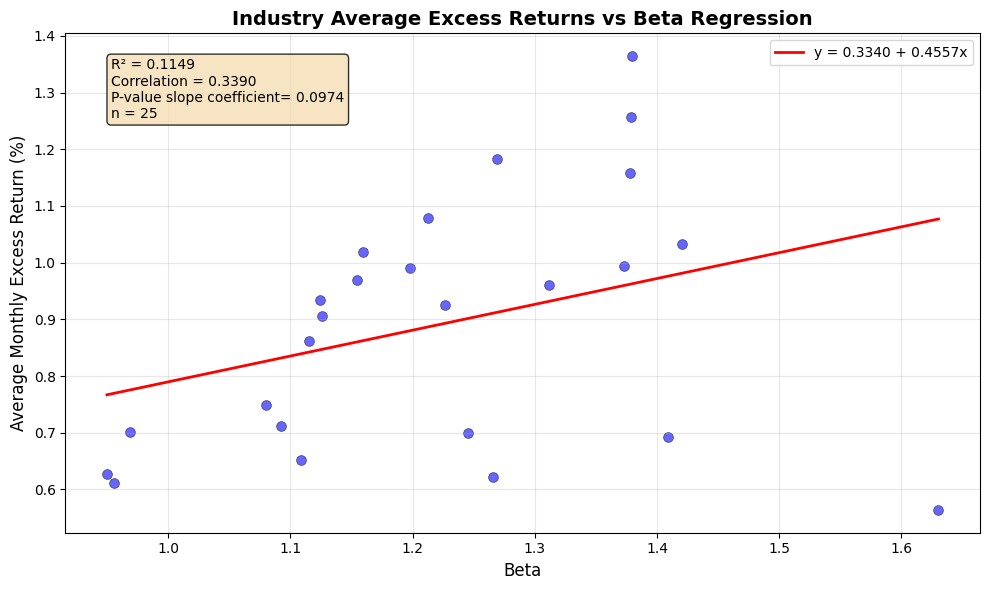

--- Fama-MacBeth Three-Factor Model Results ---
            Average  Standard Error  T-statistic
Intercept  2.221531        0.432246     5.139511
Beta      -0.562201        0.370514    -1.517353
Log_Size  -0.081171        0.031641    -2.565371
Log_BEME   0.262039        0.060976     4.297397


In [ ]:
## Loading the data

header_df = pd.read_excel('Problem_Set3.xls', sheet_name='25_Size_BEME_Portfolios', skiprows=1, nrows=2, header=None, usecols="A:Z")
# Combine the two rows into a single list of column names
column_names = [f"{str(row1).strip()}_{str(row2).strip()}" for row1, row2 in zip(header_df.iloc[0, 1:], header_df.iloc[1, 1:])]

portfolios_returns = replace_missing(pd.read_excel('Problem_Set3.xls', sheet_name='25_Size_BEME_Portfolios', skiprows=3, index_col=0, header=None, usecols="A:Z"))
portfolios_size = replace_missing(pd.read_excel('Problem_Set3.xls', sheet_name='25_Size_BEME_Portfolios', skiprows=3, index_col=0, header=None, usecols="AB:BA"))
portfolios_beme = replace_missing(pd.read_excel('Problem_Set3.xls', sheet_name='25_Size_BEME_Portfolios', skiprows=3, index_col=0, header=None, usecols="BC:CB", nrows=91))

for df in [portfolios_returns, portfolios_size, portfolios_beme]:
    df.columns = column_names

## Part b)

portfolios_betas = calculate_beta(portfolios_returns, equity_risk_prem, riskfree_rate)

print(f"Returns data shape: {portfolios_returns.shape}")
print(f"BE/ME data shape: {portfolios_beme.shape}")
print(f"Size data shape: {portfolios_size.shape}")
print(f"Betas data shape: {portfolios_betas.shape}")

print("CROSS-SECTIONAL REGRESSION RESULTS")
cs_2 = cross_sectional_reg(portfolios_returns, portfolios_betas, riskfree_rate)

## Part c)
portfolios_avg_returns = calculate_average_returns(portfolios_returns, market_proxy_table=equity_risk_prem, rf_proxy=riskfree_rate)
simple_reg_results = linear_regression(portfolios_avg_returns, portfolios_betas, verbose=False)

print("SIMPLE REGRESSION RESULTS")
print(f"Estimate for gamma_0: {simple_reg_results['intercept']}")
print(f"Estimate for gamma_M: {simple_reg_results['slope']}")
print(f"P-value for gamma_0: {simple_reg_results['p_value_intercept']}")
print(f"P-value for gamma_M: {simple_reg_results['p_value_slope']}")

## Part d)

fig1 = plot_regression(portfolios_avg_returns, portfolios_betas, simple_reg_results,
                       title="Industry Average Excess Returns vs Beta Regression",
                       xlabel="Beta",
                       ylabel="Average Monthly Excess Return (%)",
                       show_plot=True, save_plot=True)
## Part f)

portfolios_beme_monthly = yearly_to_monthly(portfolios_returns, portfolios_beme)

fama_macbeth(portfolios_returns, portfolios_betas, portfolios_size, portfolios_beme_monthly, size_lag=1, beme_lag=12)


b) Estimate Gamma0 and GammaM using Fama_MacBeth approach <br>
c) Estimate Gamma0 and GammaM using simple average approach <br>
d) The trend is: the larger the beta, the higher the excess return <br>
f) Test what factors explain why some stocks earn higher return than others <br>
The ultimate goal is to see which factors has real, independent explanatory power. According to Fama and French, Size and Value are indeed powerful predictors of stock returns. This regression was constructed to disapprove the sufficiency of the CAPM and to provide empirical foundation for the much more robust FF3 model. We found Size and BE/ME to be also significant.

Part II 2)

size of tangency portfolio weights: (25,)
size of tangency portfolio returns: (1085,)
CROSS-SECTIONAL REGRESSION RESULTS using Tangency Portfolio Returns as Market Proxy
Estimate for gamma_0: 0.0036
Estimate for gamma_M: 2.5780
P-value for gamma_0: 0.9852
P-value for gamma_M: 0.0000
SIMPLE REGRESSION RESULTS
Estimate for gamma_0: 0.0036454849976155224
Estimate for gamma_M: 2.5780045590504033
P-value for gamma_0: 0.0010458857149877598
P-value for gamma_M: 3.196010898592579e-54


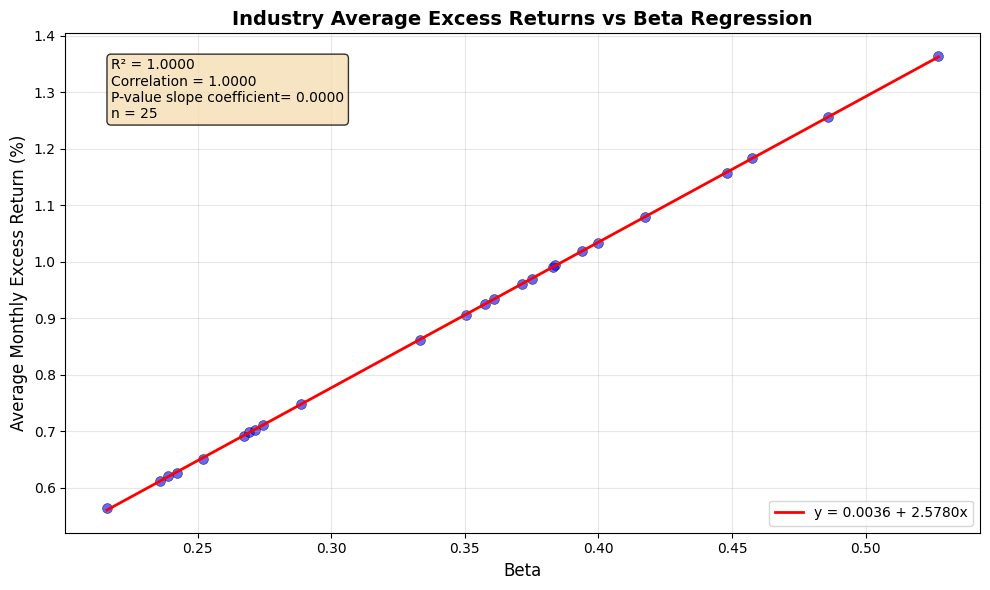

In [ ]:
def tangency_port(returns_df,rf_rate):
    """
    Computes the weights of the tangency portfolio.
    Formula: w = inv_cov_matrix.dot(avg_excess_returns) / (ones.T.dot(inv_cov_matrix).dot(avg_excess_returns))
    """
    # Calculate moments (mean and covariance)

    excess_returns = pd.DataFrame()
    for port in returns_df.columns:
        excess_returns[port] = returns_df[port] - rf_rate

    excess_returns.dropna(inplace=True)


    avg_excess_returns = excess_returns.mean()
    cov_matrix = excess_returns.cov()
    inv_cov_matrix = np.linalg.inv(cov_matrix)
    ones = np.ones(returns_df.shape[1])

    tangent_weights = inv_cov_matrix.dot(avg_excess_returns) / (ones.T.dot(inv_cov_matrix).dot(avg_excess_returns))
    # tangent_return = returns.dot(tangent_weights)
    # tangent_std_dev = np.sqrt(tangent_weights.T.dot(cov_matrix).dot(tangent_weights))
    #
    # # Solve for weights (more stable than direct inversion)
    # weights = np.linalg.solve(cov_matrix, exp_returns)
    #
    # # Normalize weights to sum to 1
    # normalized_weights = weights / weights.sum()

    return tangent_weights


in_sample_tangency_weights = tangency_port(portfolios_returns, riskfree_rate)
print("size of tangency portfolio weights:", in_sample_tangency_weights.shape)
in_sample_tangency_returns = portfolios_returns.dot(in_sample_tangency_weights)
print("size of tangency portfolio returns:", in_sample_tangency_returns.shape)

## Part b)
# Using tangency as Mkt
in_sample_portfolios_betas = calculate_beta(portfolios_returns, in_sample_tangency_returns, riskfree_rate)

print("CROSS-SECTIONAL REGRESSION RESULTS using Tangency Portfolio Returns as Market Proxy")
cs_2 = cross_sectional_reg(portfolios_returns, in_sample_portfolios_betas, riskfree_rate)

# ## Part c)
portfolios_avg_returns = calculate_average_returns(portfolios_returns, market_proxy_table=in_sample_tangency_returns, rf_proxy=riskfree_rate)
simple_reg_results = linear_regression(portfolios_avg_returns, in_sample_portfolios_betas, verbose=False)

print("SIMPLE REGRESSION RESULTS")
print(f"Estimate for gamma_0: {simple_reg_results['intercept']}")
print(f"Estimate for gamma_M: {simple_reg_results['slope']}")
print(f"P-value for gamma_0: {simple_reg_results['p_value_intercept']}")
print(f"P-value for gamma_M: {simple_reg_results['p_value_slope']}")

## Part d)

fig1 = plot_regression(portfolios_avg_returns, in_sample_portfolios_betas, simple_reg_results,
                       title="Industry Average Excess Returns vs Beta Regression",
                       xlabel="Beta",
                       ylabel="Average Monthly Excess Return (%)",
                       show_plot=True, save_plot=True)



The perfect line shows that any empirical test of CAPM is a joint test of whether the chosen market proxy is efficient, and not a test of CAPM theory itself. Therefore, the CAPM theory is empirically untestable. Roll's critique holds

Part II 3) Estimate the tangency portfolio weights using half of the data and estimate the tangency portfolio return using another half

==============Sample 1 sample=============== 
         Small_Low  Small_2  Small_3  Small_4  Small_High
0                                                       
192607       3.78    -0.41    -1.94     0.35        2.05
192609      -6.21    -0.30    -6.20    -1.64        0.86
192611       3.47     6.65     2.26    -4.70        0.54
192702       2.49    -0.30    10.97     3.75       10.21
192704       5.84     7.81     4.02     3.58        6.42
==============Sample 2 sample=============== 
         Small_Low  Small_2  Small_3  Small_4  Small_High
0                                                       
192608      -2.21    -8.73     2.44     0.61        8.40
192610      -8.62    -3.75    -5.67     5.72       -2.55
192612      13.95    -1.98     0.14     3.62        0.86
192701       0.45    -8.30    -4.79     3.23        2.02
192703       6.40    -1.75    -7.83    -2.37       -3.57
CROSS-SECTIONAL REGRESSION RESULTS -- using Out-of-Sample Tangency Portfolio Returns as Market Proxy
Estimat

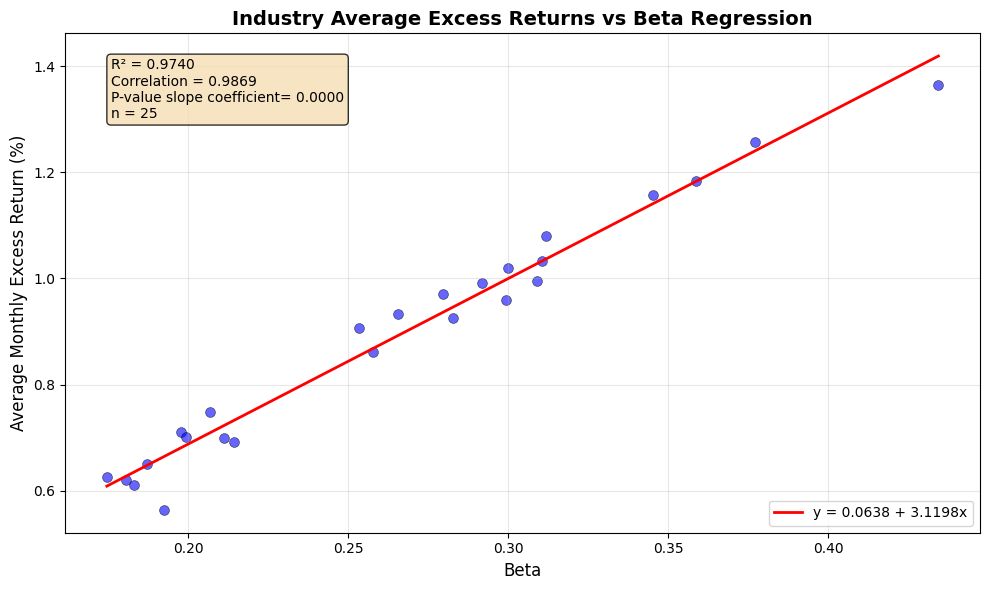

In [ ]:

# Extract year and month from the integer index
year = portfolios_returns.index // 100
month = portfolios_returns.index % 100

# Create boolean masks for odd/even years and months
is_even_year = (year % 2) == 0
is_odd_year = ~is_even_year
is_even_month = (month % 2) == 0
is_odd_month = ~is_even_month

# Sample 1: Odd months in even years, OR even months in odd years
sample1_mask = (is_odd_month & is_even_year) | (is_even_month & is_odd_year)

# Sample 2: The opposite (even months in even years, OR odd months in odd years)
sample2_mask = ~sample1_mask

# Create the two return DataFrames using the masks
returns_sample1 = portfolios_returns[sample1_mask]
returns_sample2 = portfolios_returns[sample2_mask]

print(f"==============Sample 1 sample=============== \n {returns_sample1.head().iloc[:,0:5]}")
print(f"==============Sample 2 sample=============== \n {returns_sample2.head().iloc[:,0:5]}")

# --- 2. Perform the out-of-sample calculations ---

# a. Compute weights from sample 1 and apply to sample 2
weights1 = tangency_port(returns_sample1, riskfree_rate)
tangency_returns_on_s2 = returns_sample2.dot(weights1)

# b. Compute weights from sample 2 and apply to sample 1
weights2 = tangency_port(returns_sample2, riskfree_rate)
tangency_returns_on_s1 = returns_sample1.dot(weights2)

# --- 3. Combine the results into a single return series ---
# Concatenate the two out-of-sample return series
# Since their indices are from different, non-overlapping months, they will stack correctly.
out_of_sample_tangency_returns = pd.concat([tangency_returns_on_s1, tangency_returns_on_s2])

# Sort the index to restore the original chronological order
out_of_sample_tangency_returns.sort_index(inplace=True)

print(100 * "=")
print("CROSS-SECTIONAL REGRESSION RESULTS -- using Out-of-Sample Tangency Portfolio Returns as Market Proxy")
print(100 * "=")
out_of_sample_portfolios_betas = calculate_beta(portfolios_returns, out_of_sample_tangency_returns, riskfree_rate)
cs_2 = cross_sectional_reg(portfolios_returns, out_of_sample_portfolios_betas, riskfree_rate)

## Part c)
portfolios_avg_returns = calculate_average_returns(portfolios_returns, market_proxy_table=out_of_sample_tangency_returns, rf_proxy=riskfree_rate)
simple_reg_results = linear_regression(portfolios_avg_returns, out_of_sample_portfolios_betas, verbose=False)

print(100 * "=")
print("SIMPLE REGRESSION RESULTS -- using Out-of-Sample Tangency Portfolio Returns as Market Proxy")
print(100 * "=")
print(f"Estimate for gamma_0: {simple_reg_results['intercept']:.4f}")
print(f"Estimate for gamma_M: {simple_reg_results['slope']:.4f}")
print(f"P-value for gamma_0: {simple_reg_results['p_value_intercept']:.4f}")
print(f"P-value for gamma_M: {simple_reg_results['p_value_slope']:.4f}")

## Part d)
fig1 = plot_regression(portfolios_avg_returns, out_of_sample_portfolios_betas, simple_reg_results,
                       title="Industry Average Excess Returns vs Beta Regression",
                       xlabel="Beta",
                       ylabel="Average Monthly Excess Return (%)",
                       show_plot=True, save_plot=True)

Part II 4)
Using split data to construct portfolio weights and test returns produces a weaker regression fit than using all data in-sample. This does not test CAPM itself; it tests whether the market proxy is mean-variance efficient. The evidence is therefore consistent with Roll’s critique. CAPM requires the true market portfolio to be mean-variance efficient; conversely, a portfolio being mean-variance efficient does not imply it is the market portfolio.

An ex-post mean-variance efficient portfolio need not be the market portfolio; many distinct portfolios can lie on the efficient frontier, and engineering ex-post efficiency doesn’t make a proxy the true (unobservable) market.